In [1]:
import tensorflow as tf
import numpy as np
from matplotlib import pyplot as plt

from sklearn.utils import extmath
from module_utils import * 
import sys
sys.path.append('../utils')
from Structure import *
from data_collection import *
#######################     CONFIGURATIONS     ##########################
seed = 29
train = True
save = True

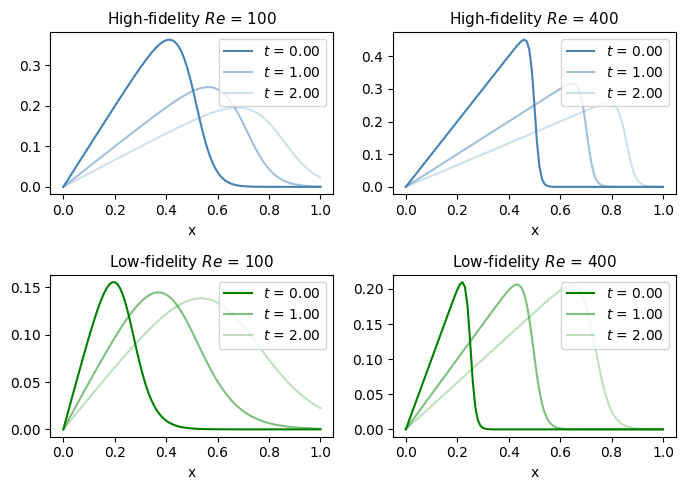

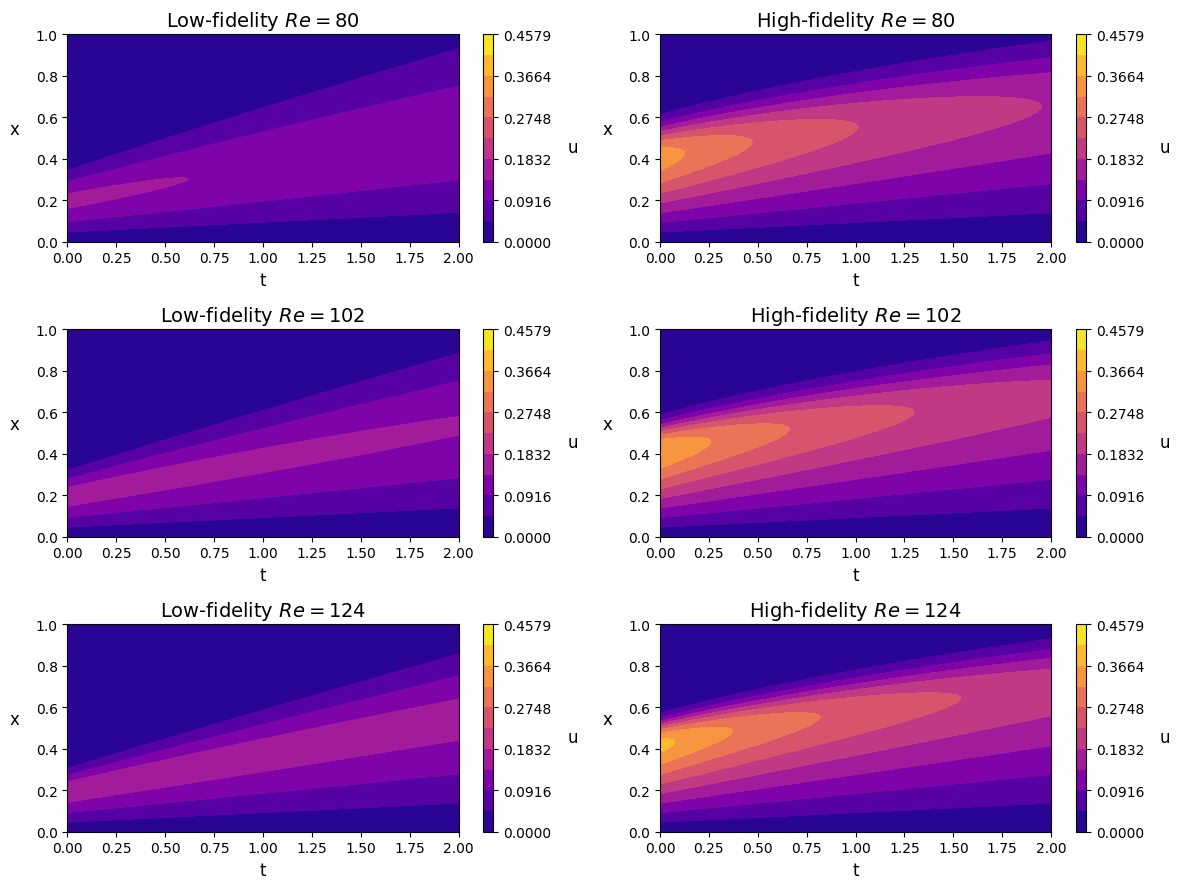

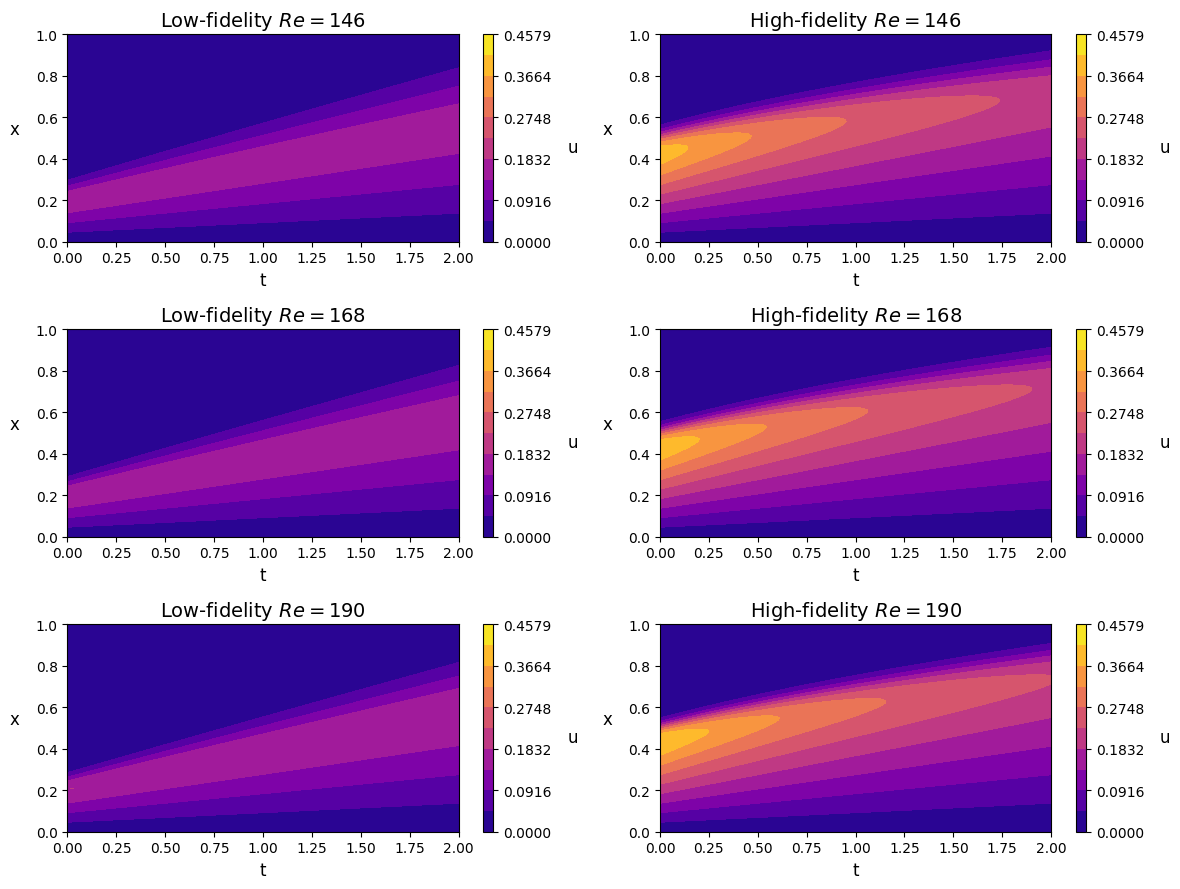

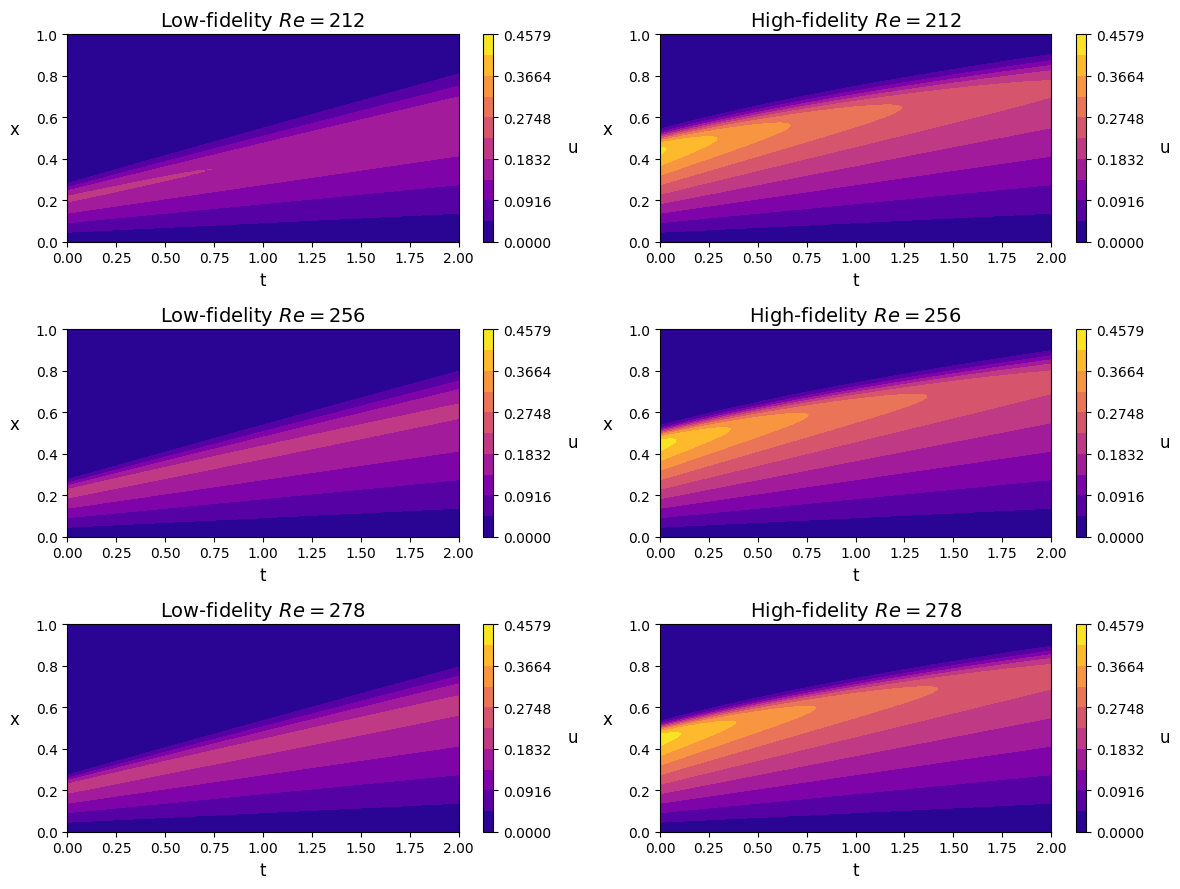

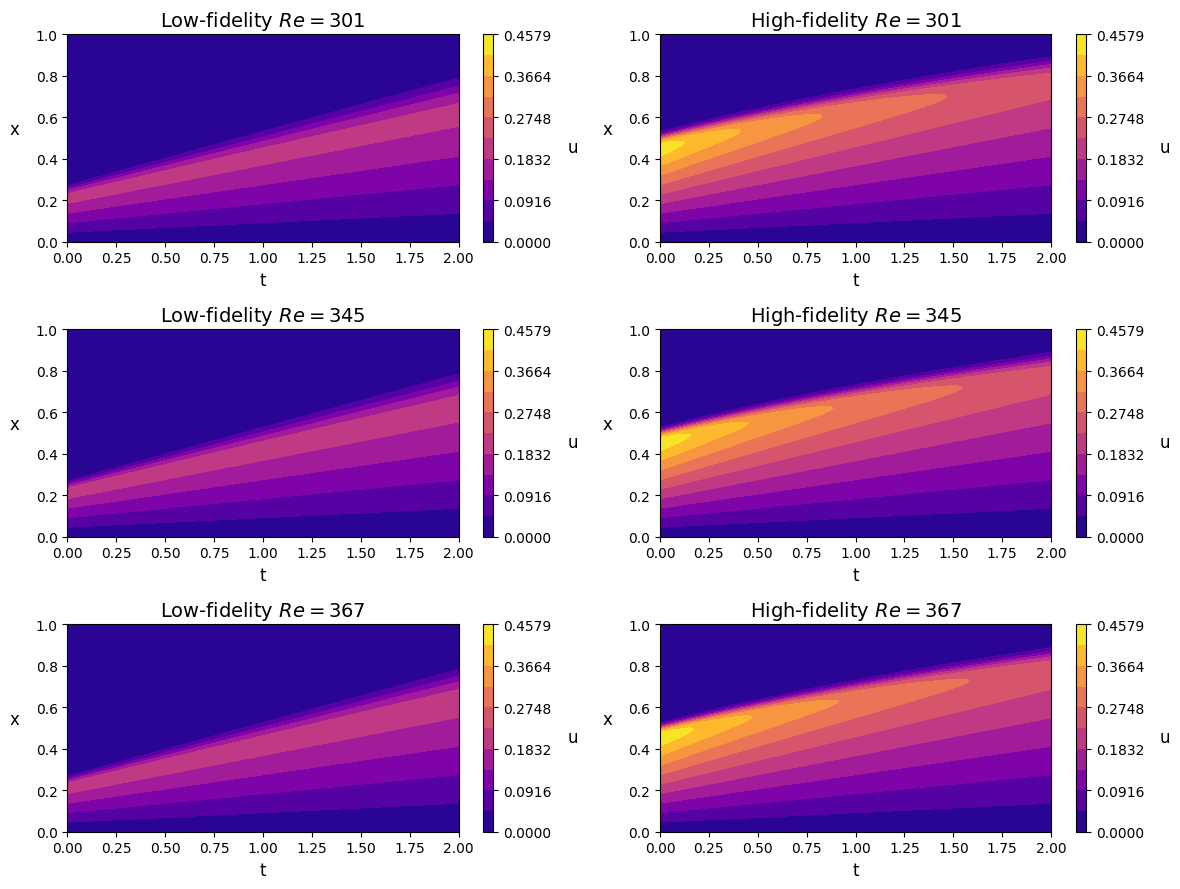

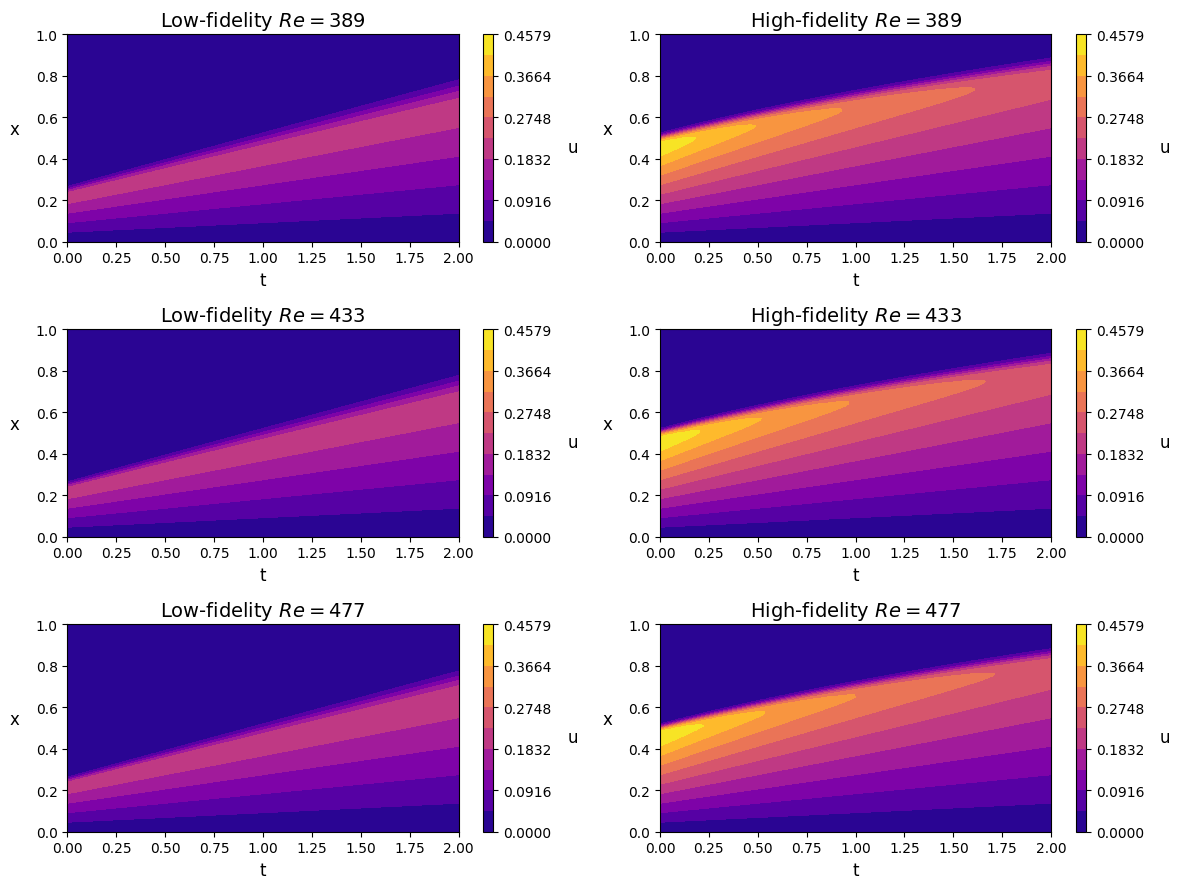

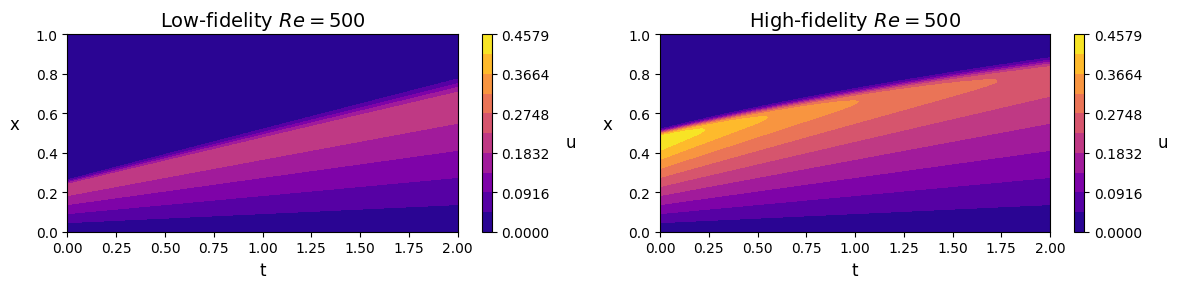

In [2]:
burger_eq = BurgerEquation(nh = 101, nt = 151, T= 2.0, L= 1.0, nre= 20, re_min = 80, re_max= 500, seed=seed)
burger_eq.generate_data()
burger_eq.plot_ground_truth_simulations()
burger_eq.plot_data()

In [3]:
burger_eq.basis=rom.basis
burger_eq.n_POD=16

NameError: name 'rom' is not defined

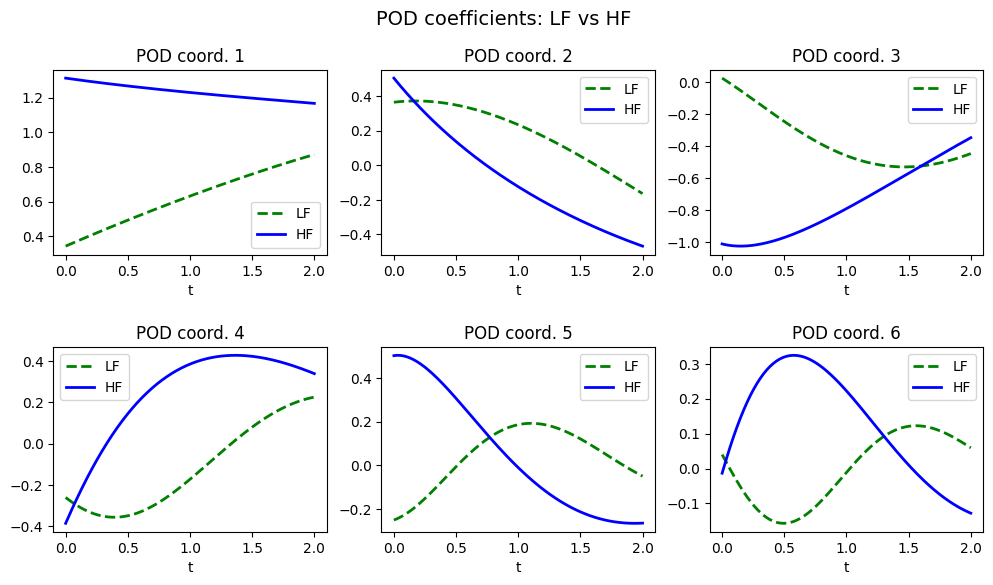

In [4]:
rom = ROM(burger_eq, n_POD=16)

input_train, output_train,input_test, output_test=rom.perform_POD()
rom.plot_POD_coefficients(ind_re=0)

The function training took 1.763700 seconds.


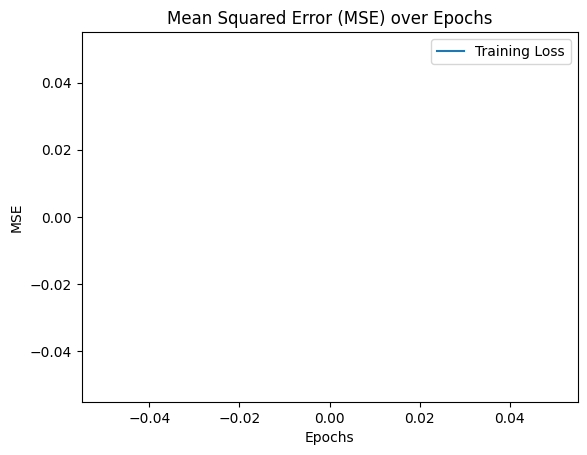

In [5]:

params_NN = { 'lay': 1,
             'nodes': 64,
             'lr':  1e-3,
             'opt': 'Adamax',
             'sequence_freq': 2,
             'sequence_length': 10,
             #'epochs':  500,
             'patience' : 50,
             'dropout' : 0.1}


definition_LSTM = {
    "network_type": "LSTM",
    "params": params_NN,
    "data_train": input_train,
    "output_train": output_train,
    "N": 5,
    "train": True,
    "do_HPO": False,
    "verbose": False
}


model = NetworkFactory.build_network(**definition_LSTM)

output_pred = model.prediction(input_test)
# Plot predicted POD coordinates
 # Re = 235

The function training took 53.057864 seconds.


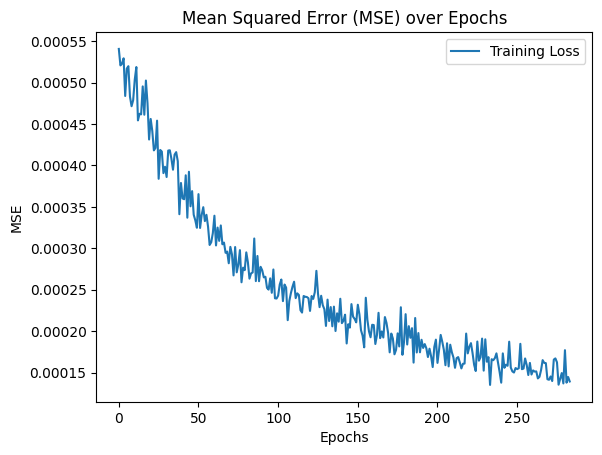

In [5]:

params_NN = { 'lay': 1,
             'nodes': 64,
             'lr':  1e-3,
             'opt': 'Adamax',
             'sequence_freq': 2,
             'sequence_length': 10,
             #'epochs':  500,
             'patience' : 50,
             'dropout' : 0.1}


definition_LSTM = {
    "network_type": "LSTM",
    "params": params_NN,
    "data_train": input_train,
    "output_train": output_train,
    "N": 500,
    "train": True,
    "do_HPO": False,
    "verbose": False
}


model = NetworkFactory.build_network(**definition_LSTM)

output_pred = model.prediction(input_test)
# Plot predicted POD coordinates
 # Re = 235

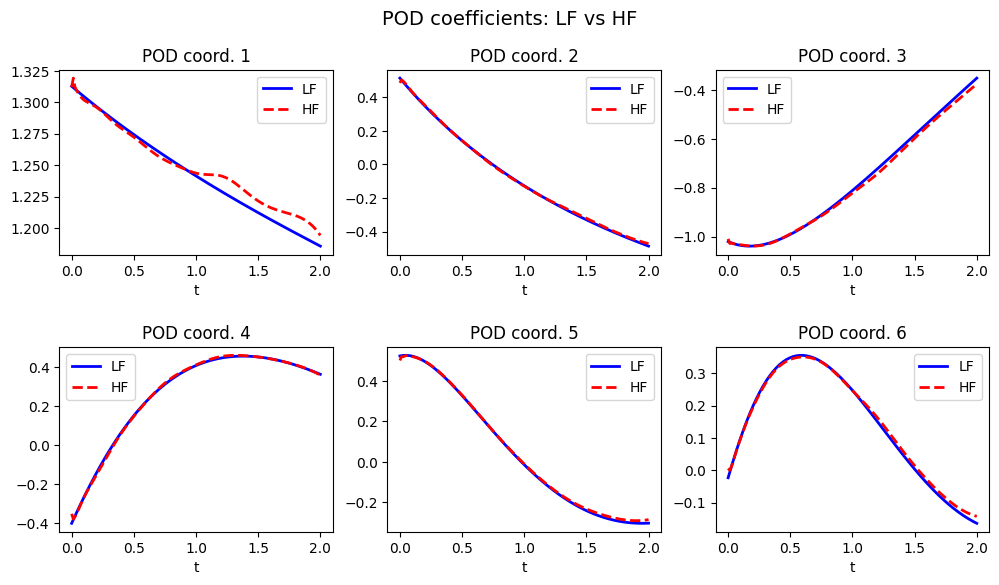

In [6]:
ind_re = [0]
rom.plot_POD_output(ind_re=ind_re, output_pred=output_pred)


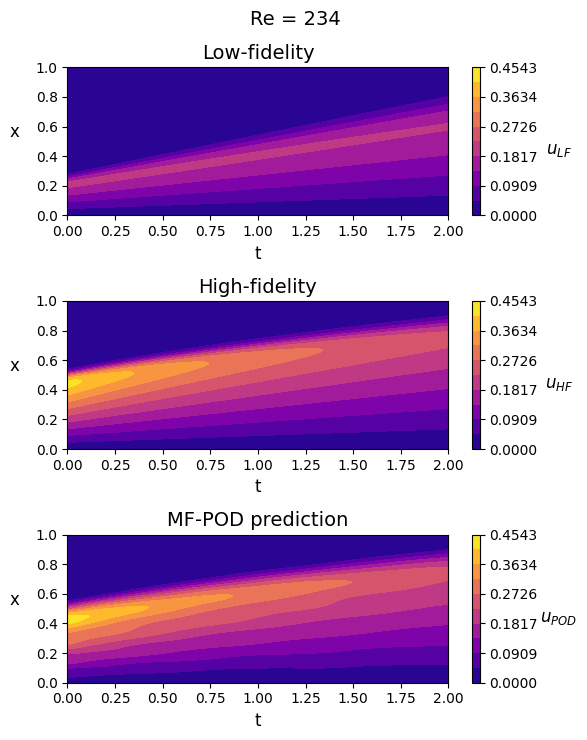

In [7]:
burger_eq.plot_comparison(output_pred, rom.get_basis(), ind_re)


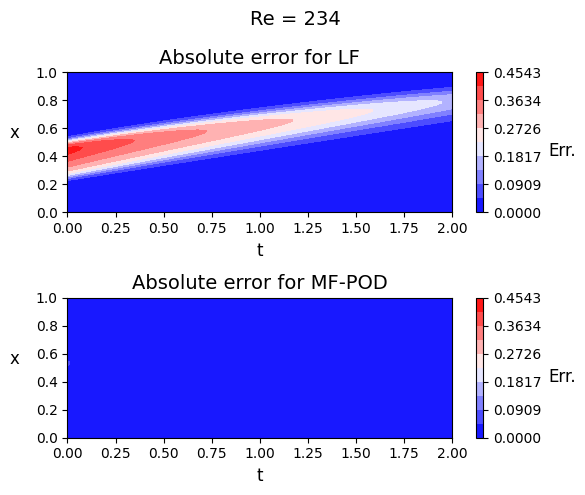

In [8]:
burger_eq.plot_error(output_pred, rom.get_basis(), ind_re)


In [ ]:
from itertools import product


In [17]:
from itertools import product

def process_data(datahf: np.ndarray, parameters: np.ndarray, t_eval: np.ndarray, Yhf: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Find the elements of a dataset nearest to the given parameters.
    
    Parameters:
    - datahf (np.ndarray): 2D array where datahf[:, 1] contains parameter values.
    - parameters (np.ndarray): 1D array of parameter values to find in datahf.
    - t_eval (np.ndarray): 2D array of evaluation times.
    - Yhf (np.ndarray): 1D array of corresponding y values.
    
    Returns:
    - nearest_x (np.ndarray): 1D array of x values closest to each t_eval.
    - y_obs (np.ndarray): 1D array of corresponding y values from Yhf.
    """
    indices = np.where(datahf[:, 1] == parameters[0])[0]
    if len(indices) == 0:
        raise ValueError(f"No observations related to parameter: {parameters[0]}")
    
    datahf_values = datahf[indices, 0].reshape(-1, 1)
    t_eval_values = t_eval.reshape(1, -1)
    differences = np.abs(datahf_values - t_eval_values)
    closest_indices = np.argmin(differences, axis=0)
    nearest_x = datahf[indices[closest_indices], 0]
    y_obs = Yhf[indices[closest_indices]%indices.shape[0]]
    
    return nearest_x, y_obs

def calculate_cov_likelihood(sigma: float, t_eval: np.ndarray) -> np.ndarray:
    """
    Calculate the covariance matrix for the likelihood.
    
    Parameters:
    - sigma (float): Standard deviation for the likelihood.
    - t_eval (np.ndarray): 2D array of evaluation times.
    
    Returns:
    - cov_likelihood (np.ndarray): 2D array representing the covariance matrix.
    """
    return sigma ** 2 * np.eye(t_eval.shape[0])

def run_simulation(datahf_x: np.ndarray, datahf: np.ndarray, mean_prior: np.ndarray, cov_prior: np.ndarray, Yhf: np.ndarray, 
                   sigma_noise: List[float], n_data: List[int], n_data_x:List[int], parameters: np.ndarray, sigma: np.ndarray, 
                   rwmh_scaling: np.ndarray, rwmh_cov: np.ndarray, rwmh_adaptive: bool, 
                   iterations: int, burnin: int, n_chains: int, final_model: Any, algo: str, 
                   forward_low_fidelity: Optional[Callable] = None) -> Tuple[np.ndarray, np.ndarray]:
    """
    Run a simulation to estimate parameters and calculate errors.
    
    Parameters:
    - datahf_x (np.ndarray): 1D array containing data.
    - datahf (np.ndarray): 2D array containing data  (t and parameter).
    - mean_prior (np.ndarray): 1D array for the mean of the prior.
    - cov_prior (np.ndarray): 2D array for the covariance of the prior.
    - Yhf (np.ndarray): 1D array of observed values.
    - sigma_noise (List[float]): List of noise levels.
    - n_data (List[int]): List of number of data points along t.
    - n_data_x (List[int]): List of number of data points along x.
    - parameters (np.ndarray): 1D array of parameters.
    - sigma (np.ndarray): 1D array of standard deviations for the likelihood.
    - rwmh_scaling (np.ndarray): 1D array of scaling factors for the RWMH algorithm.
    - rwmh_cov (np.ndarray): 2D array for the RWMH covariance.
    - rwmh_adaptive (bool): Boolean indicating if RWMH is adaptive.
    - iterations (int): Integer for the number of iterations.
    - burnin (int): Integer for the burn-in period.
    - n_chains (int): Integer for the number of chains.
    - final_model (Any): The model object with the param_inverse method.
    - algo (str): String indicating the algorithm to use.
    - forward_low_fidelity (Optional[Callable]): Low fidelity forward model function (optional).
    
    Returns:
    - best_estimate (np.ndarray): The best parameter estimate.
    - best_error (np.ndarray): The error corresponding to the best estimate.
    """
    
    # Initialize error and estimate arrays
    error_shape = (len(sigma_noise), len(n_data), len(n_data_x),len(sigma), len(rwmh_scaling))
    error = np.zeros(error_shape)
    estimates = np.zeros(error_shape)
    
    # Iterate over all combinations of parameters using itertools.product
    for (i, noise), (k, n),(w,n_x), (t, s), (j, r) in product(enumerate(sigma_noise), enumerate(n_data), enumerate(n_data_x), enumerate(sigma), enumerate(rwmh_scaling)):
        t_eval = np.linspace(np.min(datahf[:,0]), np.max(datahf[:,0]), n).reshape(-1, 1)  # Generate evaluation times
        x_eval=np.linspace(np.min(datahf_x),np.max(datahf_x),n_x).reshape(-1, 1)
        nearest_x, y_obs = process_data(datahf, parameters, t_eval, Yhf)  # Get nearest t values and observations
        cov_likelihood = calculate_cov_likelihood(s, t_eval)  # Compute the covariance for the likelihood
        
        # Perform parameter estimation and calculate error
        estimates[i, k, w,t, j], error[i, k,w, t, j] = final_model.param_inverse(
            mean_prior, x_eval, t_eval, cov_prior=cov_prior, rmwh_scaling=r, 
            cov_noise=noise,max_par=max(datahf[:,1]),cov_likelihood=cov_likelihood, y_obs=y_obs, 
            x_real=parameters, number_chains=n_chains, N=iterations, 
            burn_in=burnin, diagnostic=True, rwmh_cov=rwmh_cov, 
            rwmh_adaptive=rwmh_adaptive, algo=algo, forward_low_fidelity=forward_low_fidelity
        )
    
    # Identify the index of the minimum error
    smallest_index = np.unravel_index(np.argmin(error), error.shape)
    best_estimate = estimates[smallest_index]
    best_error = error[smallest_index]
    
    # Print the best parameters
    print(f"The best estimate is given by: sigma_noise={sigma_noise[smallest_index[0]]}, "
          f"number of data={n_data[smallest_index[1]]}, sigma={sigma[smallest_index[2]]}, "
          f"rwmh_scaling={rwmh_scaling[smallest_index[3]]}")

    return best_estimate, best_error

In [46]:
[rom.re_grid_lstm_test[0,0]]

[0.3684210526315789]

In [7]:
burger_eq.set_POD(16,rom.get_basis())

In [18]:
burger_eq.n_POD

16

: 

Sampling chain 1/2


Running chain, α = 0.17: 100%|██████████| 30/30 [00:04<00:00,  6.57it/s]


Sampling chain 2/2


Running chain, α = 0.23: 100%|██████████| 30/30 [00:04<00:00,  6.62it/s]
c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\data\inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


Estimated values are [0.224]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.224  0.056   0.177    0.358      0.019    0.014      10.0      10.0   

    r_hat  
x0   1.79  


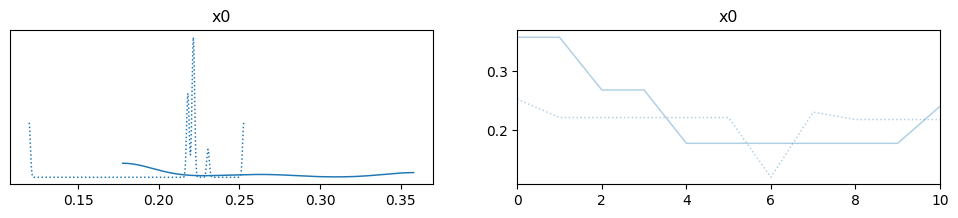

The difference between estimated values [0.14442105]



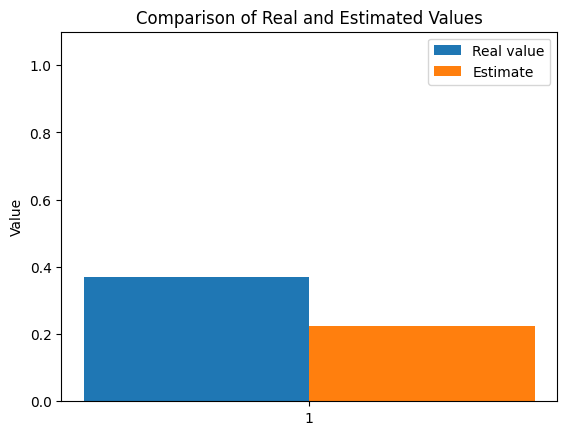

The function param_inverse took 10.996298 seconds.
Sampling chain 1/2


Running chain, α = 0.69:  50%|█████     | 15/30 [00:02<00:02,  5.97it/s]


KeyboardInterrupt: 

In [8]:
# true parameters
sigma_noise=[0.05,0.1]
n_data=[110]
index_re=0
parameter=np.array([rom.re_grid_lstm_test[index_re,0]])
#indices = np.where(input_test[:,:,1] == parameter)[0]
mean_prior=np.array([.5])
cov_prior=np.diag([.5])
# cov_linkelihood
sigma=np.array([0.3,0.5,1,2,4.])   # NB, con sigma piccolo (e.g. 1) funzia, sigma troppo gaìrande no

# adaptive metropolis
rwmh_cov = np.eye(1)
rmwh_scaling = np.array([0.5,0.2])    # 0.05 sembra problema sia esplorazione
rwmh_adaptive = True
iterations =30
burnin = 20
n_chains=2
#burger_eq.set_POD(n_POD,basis)
algo="MH"
module_directory = os.path.abspath(os.path.join('..', 'utils'))

# Add the 'utils' directory containing Structure.py to the PYTHONPATH
os.environ['PYTHONPATH'] = module_directory
sys.path.append(module_directory)


estimateMF, errorMF= run_simulation(datahf_x=burger_eq.x, 
                                    datahf=rom.input_train[:,:,[0,1]].reshape(-1, 2), 
                                    mean_prior=mean_prior, 
                                    cov_prior=cov_prior, 
                                    Yhf=output_train[index_re,], 
                                    sigma_noise=sigma_noise, 
                                    n_data=n_data, 
                                    n_data_x=[101],
                                    parameters=parameter, 
                                    sigma=sigma, 
                                    rwmh_scaling=rmwh_scaling, 
                                    rwmh_cov=rwmh_cov, 
                                    rwmh_adaptive=rwmh_adaptive, 
                                    iterations=iterations, 
                                    burnin=burnin, 
                                    n_chains= n_chains, 
                                    final_model=model, 
                                    algo=algo, 
                                    force_sequential=True,
                                    forward_low_fidelity= burger_eq._forward_low_fidelity)

In [9]:
mean_prior =np.array([2.3,0.9,0.4,1.1])
cov_prior=np.diag([ 0.1, 0.01, 0.01, 0.1])

sigma_noise = [0.25,0.5]
n_data = [50,30]
parameters =np.array([3.,1.2,1.35,1.825])
sigma = np.array([ 4.,2.])
rwmh_scaling = np.array([ 2.,0.5,1.])
rwmh_cov = np.eye(1)
rwmh_adaptive = True
iterations = 300
burnin = 200
n_chains = 2
algo = "MH"


estimateMF, errorMF= run_simulation(x_HF, mean_prior, cov_prior, y_HF, sigma_noise, n_data, parameters, sigma, rwmh_scaling, rwmh_cov, rwmh_adaptive, iterations, burnin, n_chains, final_model,algo)


NameError: name 'x_HF' is not defined